In [5]:
# College Event Feedback Analysis

# ============================================
# STEP 1: DATA CLEANING & PREPARATION
# ============================================

import pandas as pd
import numpy as np

# --------------------------------------------
# Load Dataset (Unicode-safe)
# --------------------------------------------
df = pd.read_csv(
    "FUTURE_DS_03_Dataset.csv",
    encoding="latin1"
)

# --------------------------------------------
# Initial Data Inspection
# --------------------------------------------
print(df.head())
print(df.info())
print(df.isnull().sum())

# --------------------------------------------
# Standardize Column Names
# --------------------------------------------
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

# --------------------------------------------
# Handle Missing Values
# --------------------------------------------
# Numeric columns → fill with 0
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

# Categorical columns → fill with 'Unknown'
categorical_cols = df.select_dtypes(include=["object"]).columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

# --------------------------------------------
# Convert Average / Percentage Column to Numeric
# --------------------------------------------
if "average__percentage" in df.columns:
    df["average__percentage"] = pd.to_numeric(
        df["average__percentage"], errors="coerce"
    )

# --------------------------------------------
# Remove Duplicate Rows
# --------------------------------------------
df = df.drop_duplicates()

# --------------------------------------------
# Create Derived Feature: Total Ratings
# --------------------------------------------
required_cols = [
    "weightage_1", "weightage_2",
    "weightage_3", "weightage_4",
    "weightage_5"
]

if all(col in df.columns for col in required_cols):
    df["total_ratings"] = df[required_cols].sum(axis=1)
else:
    df["total_ratings"] = 0

# --------------------------------------------
# Final Cleaned Data Check
# --------------------------------------------
print("\nCleaned Dataset Summary:")
print(df.describe())
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



   SN  Total Feedback Given  Total Configured  \
0   1                     1                12   
1   2                     1                12   
2   3                     1                12   
3   4                     1                12   
4   5                     1                12   

                                           Questions  Weightage 1  \
0  How much of the syllabus was covered in the cl...            0   
1  How well did the teachers prepare for the clas...            0   
2    How well were the teachers able to communicate?            0   
3  The teachers approach to teaching can best be...            0   
4  Fairness of the internal evaluation process by...            0   

   Weightage 2  Weightage 3  Weightage 4  Weightage 5 Average/ Percentage  \
0            0            1            0            0        3.00 / 60.00   
1            0            0            0            1       5.00 / 100.00   
2            0            0            0            1      

Dataset Shape: (580, 13)

Column Names:
 ['sn', 'total_feedback_given', 'total_configured', 'questions', 'weightage_1', 'weightage_2', 'weightage_3', 'weightage_4', 'weightage_5', 'average__percentage', 'course_name', 'basic_course', 'total_ratings']

Summary Statistics:

               sn  total_feedback_given  total_configured  weightage_1  \
count  580.000000            580.000000        580.000000   580.000000   
mean    10.500000             14.310345         92.517241     0.527586   
std      5.771259             16.488031        114.491780     1.305336   
min      1.000000              1.000000         12.000000     0.000000   
25%      5.750000              3.000000         20.000000     0.000000   
50%     10.500000              7.000000         42.000000     0.000000   
75%     15.250000             17.000000        123.000000     1.000000   
max     20.000000             74.000000        559.000000    19.000000   

       weightage_2  weightage_3  weightage_4  weightage_5  \

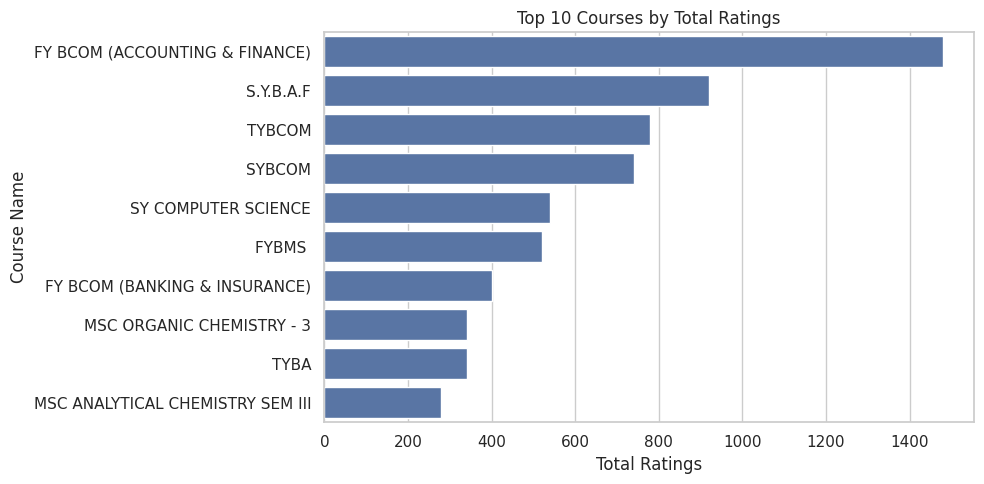

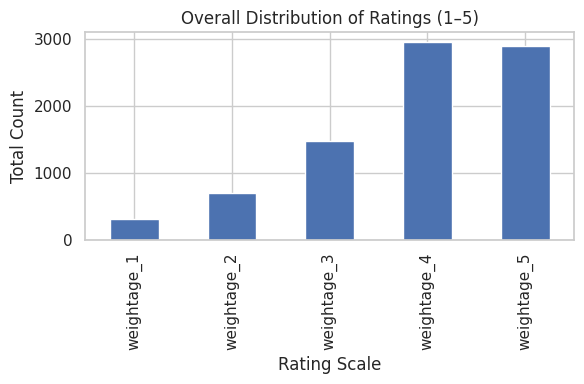

/tmp/ipython-input-129645677.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


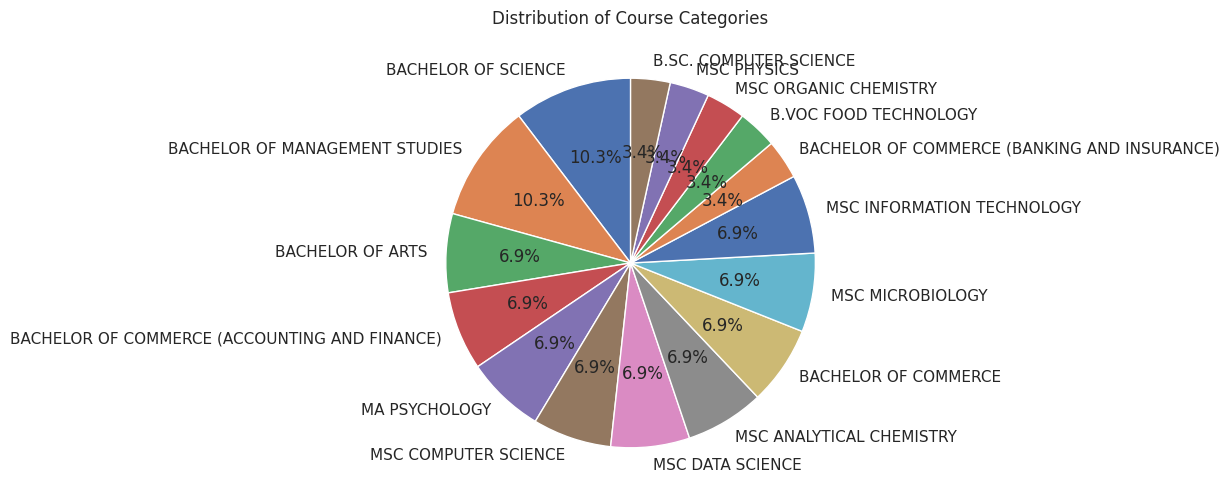

In [7]:
# ============================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# --------------------------------------------
# 1. Dataset Overview
# --------------------------------------------
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nSummary Statistics:\n")
print(df.describe())

# --------------------------------------------
# 2. Average / Percentage Analysis
# --------------------------------------------
if "average__percentage" in df.columns:
    avg_clean = df["average__percentage"].dropna()

    if avg_clean.nunique() > 1:
        plt.figure(figsize=(6, 4))
        sns.histplot(avg_clean, bins=10, kde=True)
        plt.title("Distribution of Average / Percentage Scores")
        plt.xlabel("Average / Percentage")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print("Average/Percentage column has insufficient variation for histogram.")

# --------------------------------------------
# 3. Course-wise Total Ratings (Top 10 Only)
# --------------------------------------------
if "course_name" in df.columns and "total_ratings" in df.columns:
    top_courses = (
        df.groupby("course_name")["total_ratings"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=top_courses,
        x="total_ratings",
        y="course_name"
    )
    plt.title("Top 10 Courses by Total Ratings")
    plt.xlabel("Total Ratings")
    plt.ylabel("Course Name")
    plt.tight_layout()
    plt.show()

# --------------------------------------------
# 4. Overall Rating Weightage Distribution
# --------------------------------------------
weightage_cols = [
    "weightage_1", "weightage_2",
    "weightage_3", "weightage_4",
    "weightage_5"
]

available_weights = [col for col in weightage_cols if col in df.columns]

if available_weights:
    weightage_sum = df[available_weights].sum()

    plt.figure(figsize=(6, 4))
    weightage_sum.plot(kind="bar")
    plt.title("Overall Distribution of Ratings (1–5)")
    plt.xlabel("Rating Scale")
    plt.ylabel("Total Count")
    plt.tight_layout()
    plt.show()

# --------------------------------------------
# 5. Course Category Distribution
# --------------------------------------------
if "basic_course" in df.columns:
    category_counts = df["basic_course"].value_counts()

    plt.figure(figsize=(6, 6))
    category_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
    plt.title("Distribution of Course Categories")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


Numeric Summary:

count    580.000000
mean       3.842792
std        0.628932
min        1.333333
25%        3.500000
50%        3.916667
75%        4.250000
max        5.000000
Name: weighted_average_rating, dtype: float64


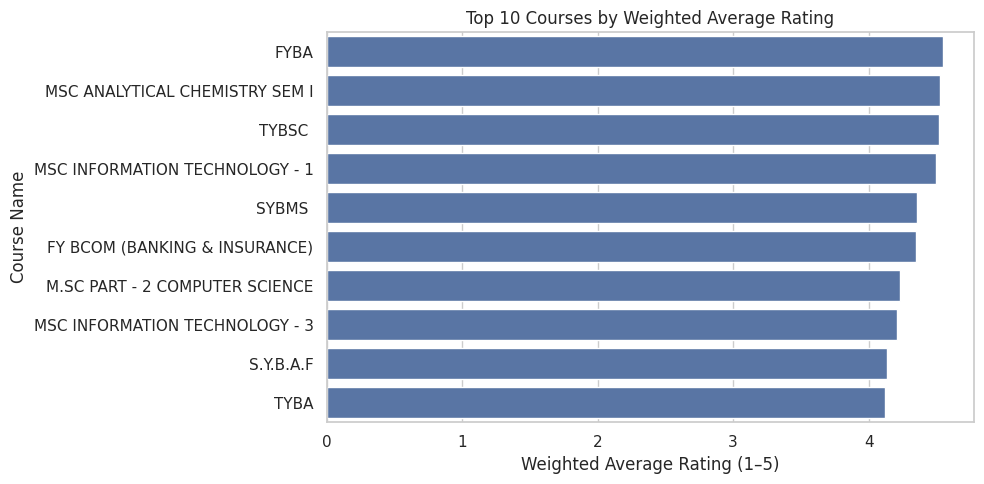

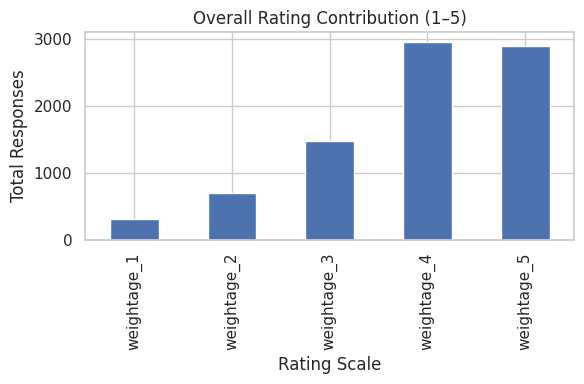

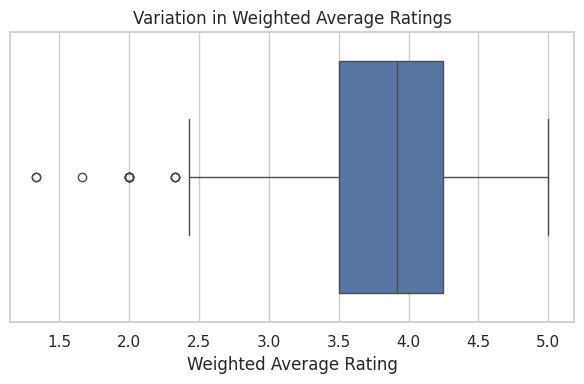

In [10]:
# ============================================
# STEP 3: NUMERIC ANALYSIS (FINAL & ROBUST)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# --------------------------------------------
# 1. Create Weighted Average Rating (1–5)
# --------------------------------------------
weightage_cols = {
    "weightage_1": 1,
    "weightage_2": 2,
    "weightage_3": 3,
    "weightage_4": 4,
    "weightage_5": 5
}

# Ensure required columns exist
available_cols = [c for c in weightage_cols if c in df.columns]

if available_cols:
    df["weighted_score_sum"] = sum(
        df[col] * weightage_cols[col] for col in available_cols
    )
    df["rating_count"] = df[available_cols].sum(axis=1)

    df["weighted_average_rating"] = df.apply(
        lambda x: x["weighted_score_sum"] / x["rating_count"]
        if x["rating_count"] > 0 else 0,
        axis=1
    )

# --------------------------------------------
# 2. Summary Statistics
# --------------------------------------------
print("Numeric Summary:\n")
print(df["weighted_average_rating"].describe())

# --------------------------------------------
# 3. Top 10 Courses by Weighted Average Rating
# --------------------------------------------
if "course_name" in df.columns:
    top_courses = (
        df.groupby("course_name")["weighted_average_rating"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=top_courses,
        x="weighted_average_rating",
        y="course_name"
    )
    plt.title("Top 10 Courses by Weighted Average Rating")
    plt.xlabel("Weighted Average Rating (1–5)")
    plt.ylabel("Course Name")
    plt.tight_layout()
    plt.show()

# --------------------------------------------
# 4. Overall Rating Contribution (1–5)
# --------------------------------------------
rating_totals = df[list(weightage_cols.keys())].sum()

plt.figure(figsize=(6, 4))
rating_totals.plot(kind="bar")
plt.title("Overall Rating Contribution (1–5)")
plt.xlabel("Rating Scale")
plt.ylabel("Total Responses")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 5. Variability in Weighted Ratings
# --------------------------------------------
valid_scores = df["weighted_average_rating"][df["weighted_average_rating"] > 0]

if valid_scores.nunique() > 1:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=valid_scores)
    plt.title("Variation in Weighted Average Ratings")
    plt.xlabel("Weighted Average Rating")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough variation for boxplot.")


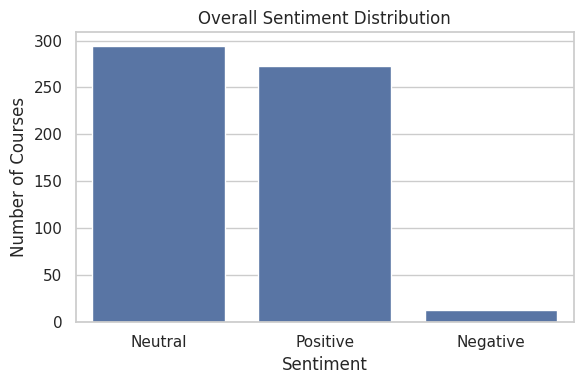

/tmp/ipython-input-3868490327.py:61: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


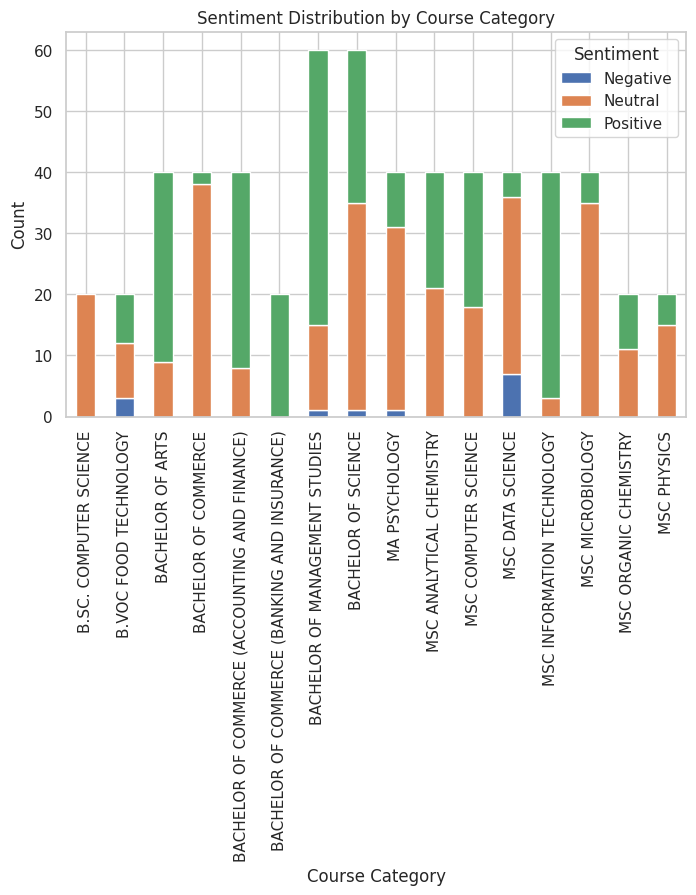

Sentiment Percentage Distribution:

sentiment
Neutral     50.69
Positive    47.07
Negative     2.24
Name: count, dtype: float64


In [11]:
# ============================================
# STEP 4: SENTIMENT ANALYSIS (RATING-BASED)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# --------------------------------------------
# 1. Create Sentiment Labels from Ratings
# --------------------------------------------
# Using weighted average rating (from Page 8)

def assign_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score >= 2.5:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["weighted_average_rating"].apply(assign_sentiment)

# --------------------------------------------
# 2. Sentiment Distribution
# --------------------------------------------
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Courses")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 3. Sentiment by Course Category
# --------------------------------------------
if "basic_course" in df.columns:
    sentiment_category = (
        df.groupby(["basic_course", "sentiment"])
        .size()
        .unstack(fill_value=0)
    )

    sentiment_category.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 5)
    )
    plt.title("Sentiment Distribution by Course Category")
    plt.xlabel("Course Category")
    plt.ylabel("Count")
    plt.legend(title="Sentiment")
    plt.tight_layout()
    plt.show()

# --------------------------------------------
# 4. Sentiment Percentage Summary
# --------------------------------------------
sentiment_percentage = (
    sentiment_counts / sentiment_counts.sum()
) * 100

print("Sentiment Percentage Distribution:\n")
print(sentiment_percentage.round(2))


Correlation Matrix:

                         weightage_1  weightage_2  weightage_3  weightage_4  \
weightage_1                 1.000000     0.435847     0.480386     0.248107   
weightage_2                 0.435847     1.000000     0.601163     0.454875   
weightage_3                 0.480386     0.601163     1.000000     0.607561   
weightage_4                 0.248107     0.454875     0.607561     1.000000   
weightage_5                 0.253201     0.456325     0.531790     0.727531   
total_ratings               0.426196     0.634037     0.771235     0.912457   
weighted_average_rating    -0.259137    -0.277498    -0.162755     0.100899   

                         weightage_5  total_ratings  weighted_average_rating  
weightage_1                 0.253201       0.426196                -0.259137  
weightage_2                 0.456325       0.634037                -0.277498  
weightage_3                 0.531790       0.771235                -0.162755  
weightage_4                 0.

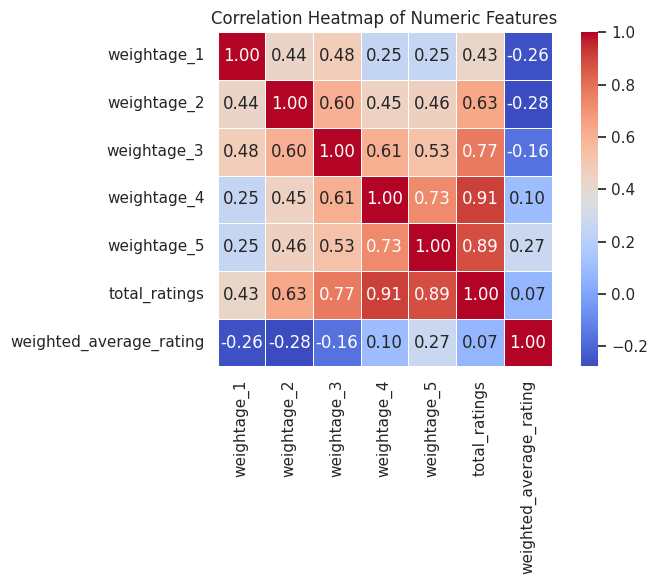

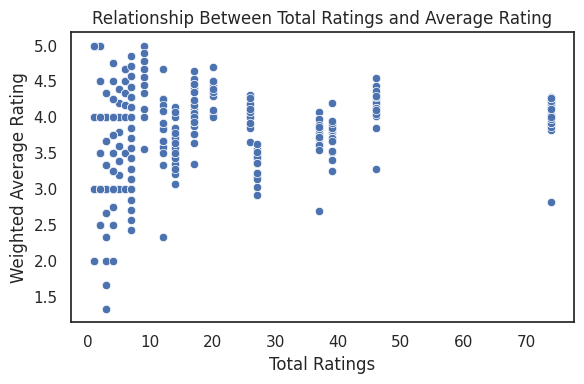

In [12]:
# ============================================
# STEP 5: CORRELATION ANALYSIS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="white")

# --------------------------------------------
# 1. Select Numeric Columns for Correlation
# --------------------------------------------
numeric_cols = [
    "weightage_1",
    "weightage_2",
    "weightage_3",
    "weightage_4",
    "weightage_5",
    "total_ratings",
    "weighted_average_rating"
]

available_numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_df = df[available_numeric_cols]

# --------------------------------------------
# 2. Compute Correlation Matrix
# --------------------------------------------
correlation_matrix = corr_df.corr()

print("Correlation Matrix:\n")
print(correlation_matrix)

# --------------------------------------------
# 3. Correlation Heatmap (Clean & Readable)
# --------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 4. Relationship Between Total Ratings and Weighted Average Rating
# --------------------------------------------
if "total_ratings" in df.columns and "weighted_average_rating" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        x="total_ratings",
        y="weighted_average_rating",
        data=df
    )
    plt.title("Relationship Between Total Ratings and Average Rating")
    plt.xlabel("Total Ratings")
    plt.ylabel("Weighted Average Rating")
    plt.tight_layout()
    plt.show()


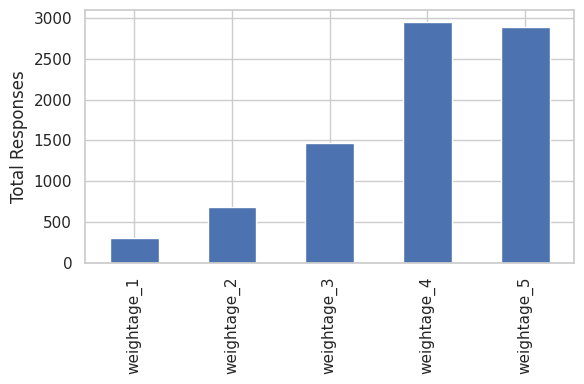

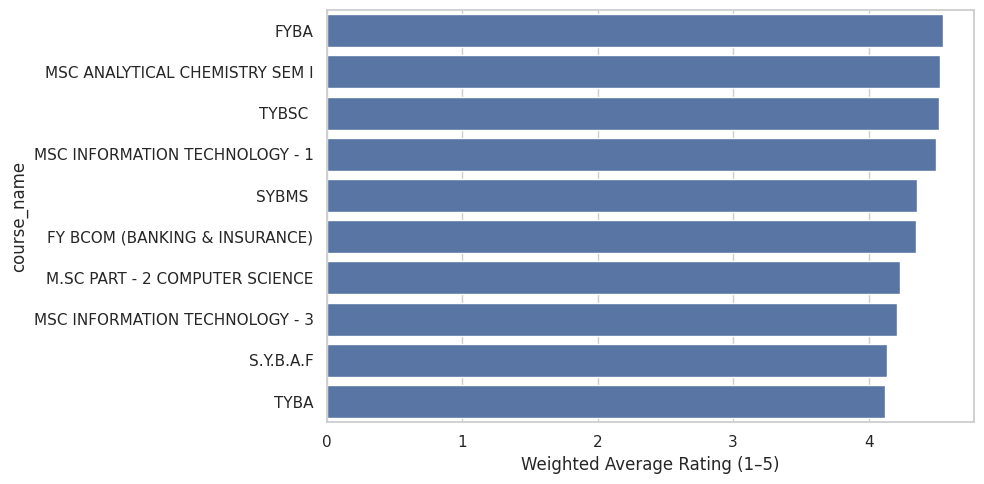

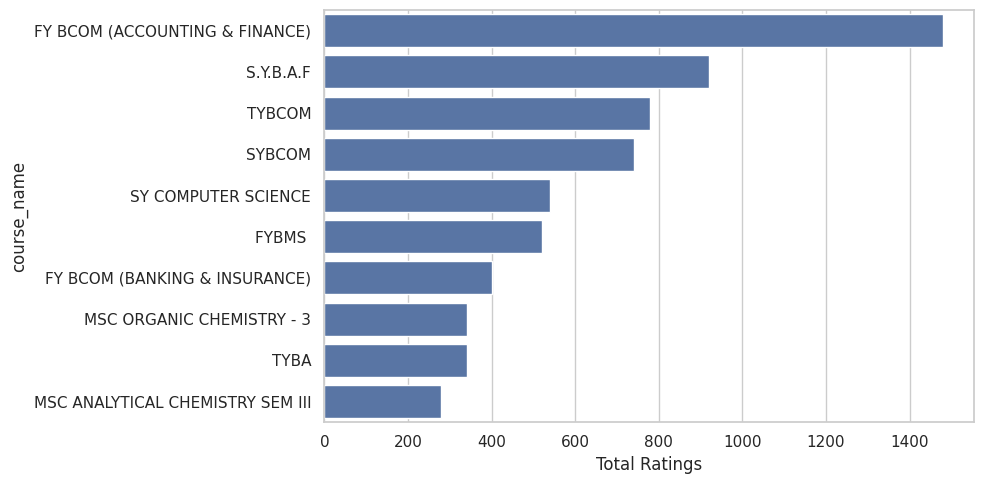

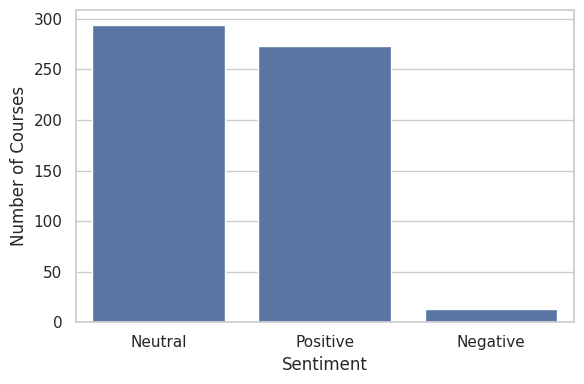

/tmp/ipython-input-2393388391.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


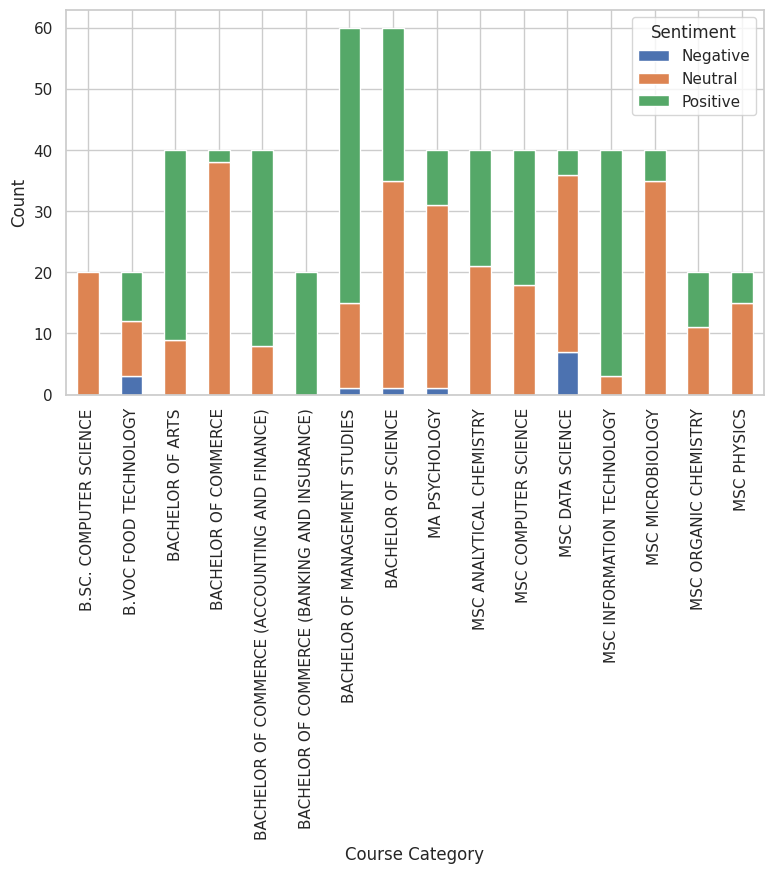

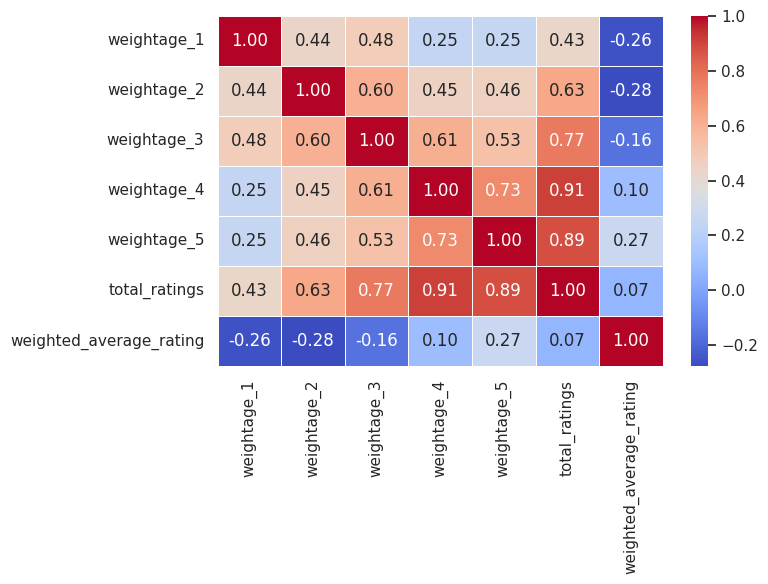

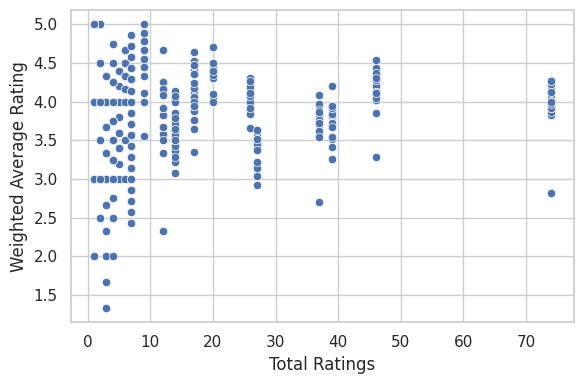

/tmp/ipython-input-2393388391.py:164: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


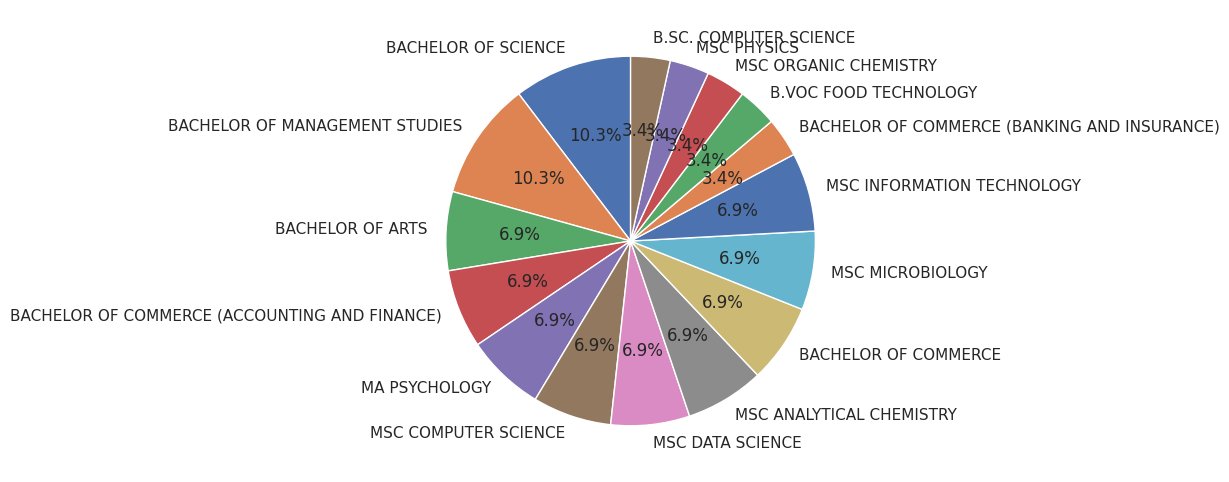

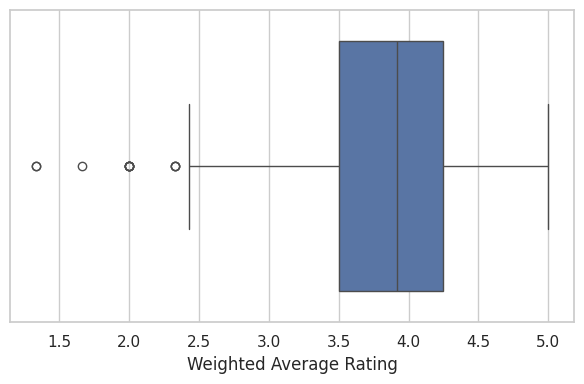

In [19]:
# ============================================
# MASTER VISUALIZATION SCRIPT
# College Event Feedback Analysis
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# --------------------------------------------
# 1. Overall Rating Distribution (1–5)
# --------------------------------------------
weightage_cols = {
    "weightage_1": 1,
    "weightage_2": 2,
    "weightage_3": 3,
    "weightage_4": 4,
    "weightage_5": 5
}

rating_totals = df[list(weightage_cols.keys())].sum()

plt.figure(figsize=(6, 4))
rating_totals.plot(kind="bar")


plt.ylabel("Total Responses")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 2. Top 10 Courses by Weighted Average Rating
# --------------------------------------------
top_courses_rating = (
    df.groupby("course_name")["weighted_average_rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_courses_rating,
    x="weighted_average_rating",
    y="course_name"
)

plt.xlabel("Weighted Average Rating (1–5)")

plt.tight_layout()
plt.show()

# --------------------------------------------
# 3. Top 10 Courses by Total Ratings
# --------------------------------------------
top_courses_volume = (
    df.groupby("course_name")["total_ratings"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_courses_volume,
    x="total_ratings",
    y="course_name"
)

plt.xlabel("Total Ratings")

plt.tight_layout()
plt.show()

# --------------------------------------------
# 4. Sentiment Distribution
# --------------------------------------------
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Courses")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 5. Sentiment by Course Category (Stacked Bar)
# --------------------------------------------
sentiment_category = (
    df.groupby(["basic_course", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.xlabel("Course Category")
plt.ylabel("Count")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 6. Correlation Heatmap
# --------------------------------------------
corr_columns = [
    "weightage_1", "weightage_2", "weightage_3",
    "weightage_4", "weightage_5",
    "total_ratings", "weighted_average_rating"
]

corr_df = df[corr_columns]
correlation_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.tight_layout()
plt.show()

# --------------------------------------------
# 7. Total Ratings vs Weighted Average Rating
# --------------------------------------------
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x="total_ratings",
    y="weighted_average_rating"
)

plt.xlabel("Total Ratings")
plt.ylabel("Weighted Average Rating")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 8. Course Category Distribution
# --------------------------------------------
category_counts = df["basic_course"].value_counts()

plt.figure(figsize=(6, 6))
category_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)

plt.ylabel("")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 9. Variability in Satisfaction Scores
# --------------------------------------------
valid_scores = df["weighted_average_rating"][df["weighted_average_rating"] > 0]

if valid_scores.nunique() > 1:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=valid_scores)

    plt.xlabel("Weighted Average Rating")
    plt.tight_layout()
    plt.show()
